# Titanic EDA 실습

## 실습 목표 및 분석 질문

EDA를 시작하기 전에 질문을 정해야 함.

이번 실습의 핵심 질문:

1. Titanic 승객의 생존 여부는 어떤 변수와 관련이 있어 보이는가?
2. 결측치나 이상값 때문에 전처리가 필요한 컬럼은 무엇인가?
3. 모델링을 한다면 어떤 파생변수를 만들 수 있는가?
4. 최종적으로 어떤 인사이트를 보고서에 쓸 수 있는가?

In [1]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import boxplot

In [6]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

설정된 한글 폰트: Malgun Gothic


## 01. 데이터 수집 및 로드

실행 위치가 달라도 동작하도록 여러 데이터 경로 후보를 확인함.

In [88]:
raw_df= pd.read_csv('./data/titanic.csv')

In [10]:
df.head()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64


## 02. 데이터 구조 및 변수 이해

먼저 행/열 수, 컬럼명, 자료형, 샘플 데이터를 확인함.

In [15]:
print('행/열 수 : ',df.shape)
print('컬럼명: ',df.columns.tolist())
print('자료형:',df.dtypes)

행/열 수 :  (891, 12)
컬럼명:  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
자료형: PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


## 03. 데이터 요약 및 기술 통계

수치형은 평균, 표준편차, 사분위수 확인.
범주형은 고유값 수, 최빈값, 빈도 확인.

In [23]:
#수치형 컬럼 기술 통계 확인
numeric_summary=df.describe().T

#범주형 컬럼의 기술 통계 확인
categorical_summery = df.describe(include=['object','string','category']).T
categorical_summery

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [33]:
# 타겟 변수와 주요 범주형 변수의 값 분포 확인
target_counts = df['Survived'].value_counts().rename(index={0:'사망',1:'생존'})


target_counts  = (df['Survived'].value_counts(normalize=True)*100).round(1).rename(index={0:'사망',1:'생존'})
target_counts

print('생존 여부 count')
display(target_counts.to_frame('count'))

print('생존 여부 비율(%)')
display(target_counts.to_frame('ratio'))

for col in ['Pclass','Sex','Embarked','SibSp','Parch'] :
    print(col,'값 분포')
    display(df[col].value_counts(dropna=False).to_frame('count'))

생존 여부 count


,count
Survived,
사망,61.6
생존,38.4


생존 여부 비율(%)


,ratio
Survived,
사망,61.6
생존,38.4


Pclass 값 분포


...

,count
Embarked,
S,644
C,168
Q,77
NaN,2


SibSp 값 분포


,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


Parch 값 분포


,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


## 04. 결측치, 중복, 이상값 탐지

EDA에서는 바로 삭제하지 않고 먼저 **얼마나, 어디에, 왜** 있는지 확인함.

In [37]:
missing_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_ratio' :( df.isna().sum() / df.shape[0]) * 100
}).sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_ratio
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [41]:
#중복 여부와 식별자 컬럼의 고유성 확인
print('전체 행 중복 수 :',df.duplicated().sum())
print('PassengerId 중복 수 :',df.duplicated('PassengerId').sum())

전체 행 중복 수 : 0
PassengerId 중복 수 : 0


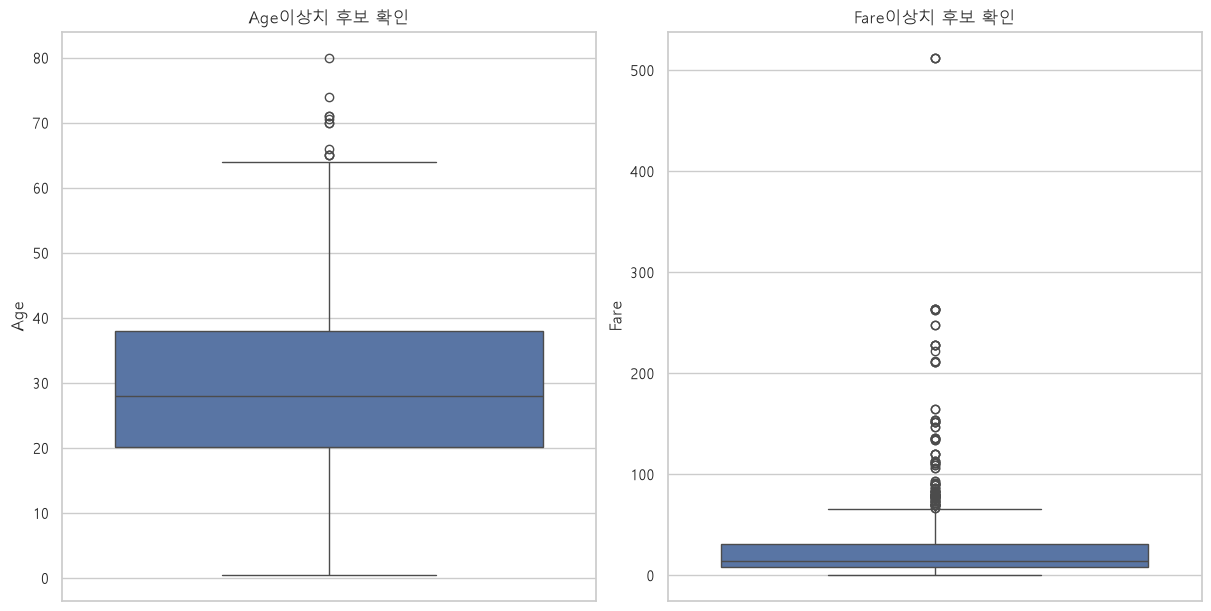

Age: Q1=20.12, Q3=38.00, IQR=17.88, 이상값 후보 수=11
Fare: Q1=7.91, Q3=31.00, IQR=23.09, 이상값 후보 수=116


In [56]:
# Age, Fare 컬럼의 이상치 후보를 확인
check_cols=['Age','Fare']

fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(12,6),constrained_layout=True)

for a,col in zip(ax,check_cols):
    sns.boxplot(data=df,y=col,ax=a)
    a.set_title(f'{col}이상치 후보 확인')

plt.show()

# IQR 방식으로 이상값 후보 수 계산
for col in check_cols:
    # Q1: 1사분위수, 하위 25% 지점
    q1 = df[col].quantile(0.25)

    # Q3: 3사분위수, 상위 25% 지점
    q3 = df[col].quantile(0.75)

    # IQR: 가운데 50% 데이터가 퍼져 있는 범위
    iqr = q3 - q1

    # IQR 기준 하한/상한 계산
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 하한보다 작거나 상한보다 큰 값을 이상값 후보로 계산
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, 이상값 후보 수={outlier_count}")


## 05. 변수별 분포 시각화

개별 변수의 분포를 먼저 확인한 뒤, 타깃 변수와 연결해서 봄.

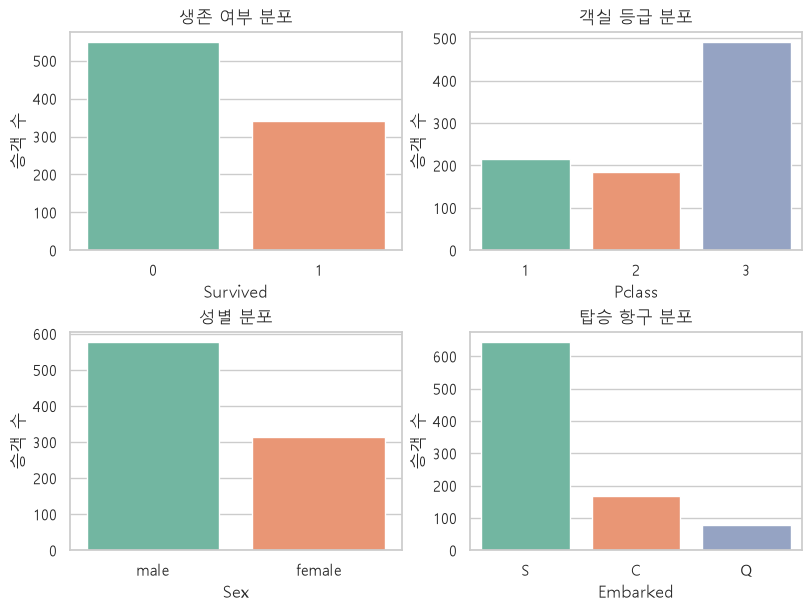

In [68]:
# 생존 여부, 객실 등급, 성별, 탑승 항구 분포를 확인
fig,axes = plt.subplots(2, 2,figsize=(8,6),constrained_layout=True)
axes = axes.ravel() #2차원을 1차원으로 줄임

plot_specs = [
    ("Survived", "생존 여부 분포"),
    ("Pclass", "객실 등급 분포"),
    ("Sex", "성별 분포"),
    ("Embarked", "탑승 항구 분포"),
]

for ax, (col,title) in zip(axes ,plot_specs):
    sns.countplot(data=df,x=col,ax=ax,hue=col,palette='Set2',legend=False)
    ax.set_title(title)
    ax.set_ylabel( '승객 수' )

plt.show()

Text(0.5, 1.0, '요금 분포')

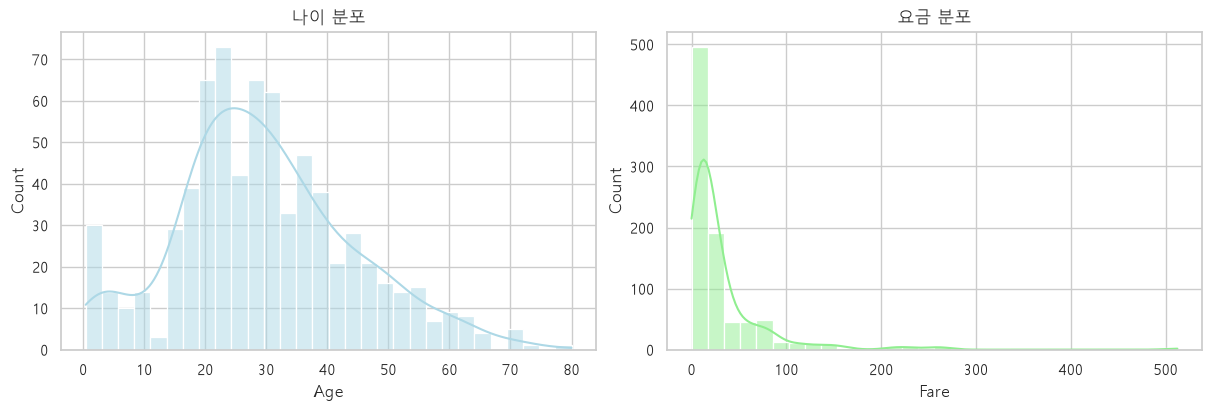

In [76]:
# Age, Fate 히스토그램을 이용한 분포 확인
fig,axes = plt.subplots(1,2,figsize=(12,4),constrained_layout=True)

sns.histplot(data=df,
             x='Age',
             ax=axes[0],
             bins=30,
             kde=True,
             color='lightblue',)
axes[0].set_title('나이분포')

sns.histplot(data=df,
             x='Fare',
             ax=axes[1],
             bins=30,
             kde=True,
             color='lightgreen',)
axes[0].set_title('나이 분포')
axes[1].set_title('요금 분포')

## 06. 변수 간 관계 시각화

이제 타깃인 `Survived`와 주요 변수의 관계를 확인함.

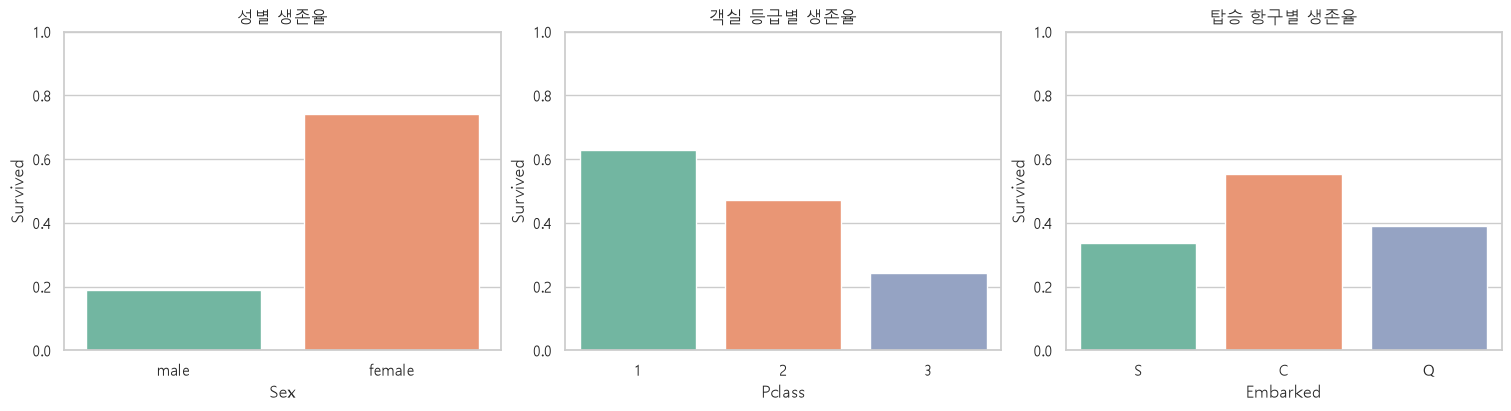

count   mean
Sex    Pclass              
female 1          94  0.968
       2          76  0.921
       3         144  0.500
male   1         122  0.369
       2         108  0.157
       3         347  0.135

In [77]:
# 성별, 객실 등급, 탑승 항구별 생존율 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", palette="Set2", errorbar=None, legend=False, ax=axes[0])
axes[0].set_title("성별 생존율")
axes[0].set_ylim(0, 1)

sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", palette="Set2", errorbar=None, legend=False, ax=axes[1])
axes[1].set_title("객실 등급별 생존율")
axes[1].set_ylim(0, 1)

sns.barplot(data=df, x="Embarked", y="Survived", hue="Embarked", palette="Set2", errorbar=None, legend=False, ax=axes[2])
axes[2].set_title("탑승 항구별 생존율")
axes[2].set_ylim(0, 1)

plt.show()

survival_summary = df.groupby(["Sex", "Pclass"], observed=True)["Survived"].agg(["count", "mean"]).round(3)
survival_summary

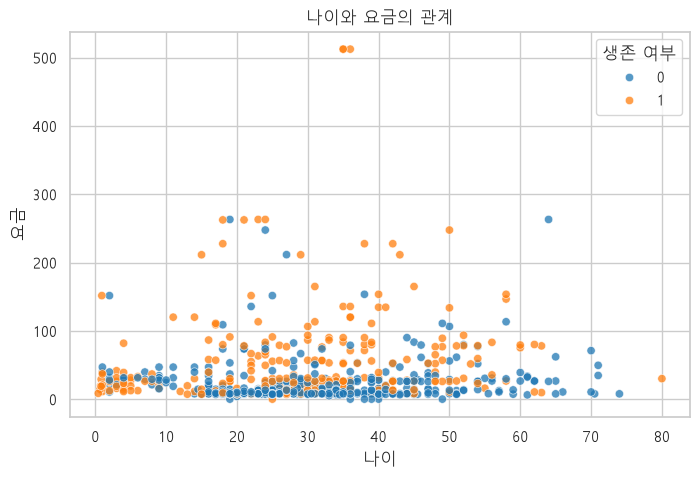

In [79]:
# 나이와 요금 관계를 생존 여부 색상으로 확인
scatter_df = df.dropna(subset=["Age", "Fare", "Survived"])

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=scatter_df,
    x="Age",
    y="Fare",
    hue="Survived",
    palette={0: "tab:blue", 1: "tab:orange"},
    alpha=0.75,
)
plt.title("나이와 요금의 관계")
plt.xlabel("나이")
plt.ylabel("요금")
plt.legend(title="생존 여부")
plt.show()

## 07. 상관관계 및 교차분석

수치형 변수끼리는 상관계수, 범주형 변수와 타깃은 교차표로 확인함.

## 08. 데이터 전처리 방향 정리

EDA에서 발견한 문제를 바탕으로 전처리 계획을 세움.

주의: 원본 `raw_df`는 유지하고, `eda_df`라는 복사본에서 전처리 실습을 진행함.

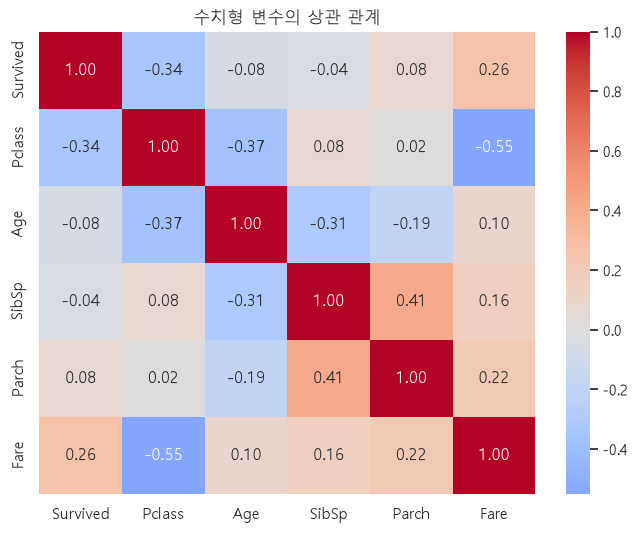

In [85]:
# 수치형 변수의 상관관계
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_mat = df[corr_cols].corr(numeric_only=True)
#corr_mat

# 상관관계를 이용해서heatmap  생성
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat,annot=True,fmt='.2f',cmap="coolwarm",center=0)
plt.title('수치형 변수의 상관 관계')
plt.show()

성별 생존 비율


Survived,0,1
Sex,,
female,0.258,0.742
male,0.811,0.189


객실 등급별 생존 비율


Survived,0,1
Pclass,,
1,0.370,0.630
2,0.527,0.473
3,0.758,0.242


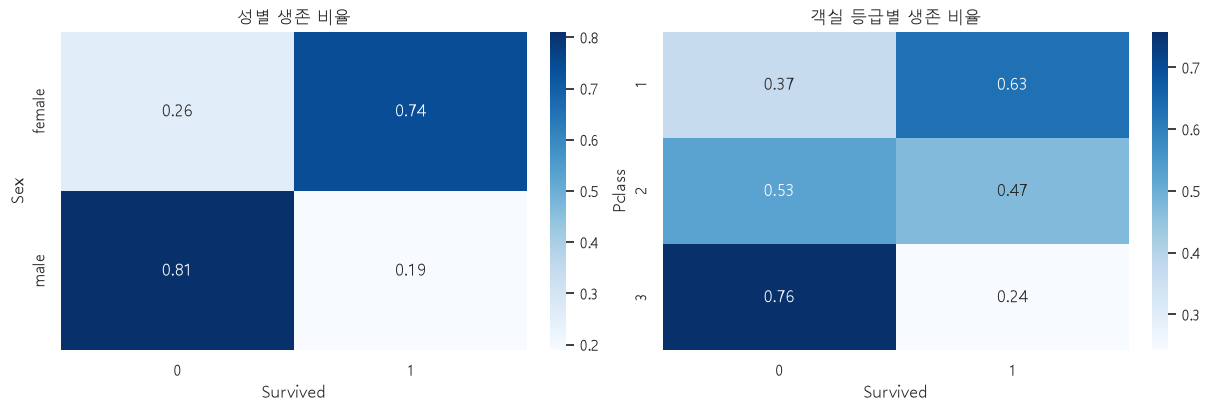

In [86]:
# 성별/객실등급별 생존율을 교차표와 히트맵으로 확인
sex_survival = pd.crosstab(df["Sex"], df["Survived"], normalize="index").round(3)
pclass_survival = pd.crosstab(df["Pclass"], df["Survived"], normalize="index").round(3)

print("성별 생존 비율")
display(sex_survival)
print("객실 등급별 생존 비율")
display(pclass_survival)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.heatmap(sex_survival, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("성별 생존 비율")

sns.heatmap(pclass_survival, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set_title("객실 등급별 생존 비율")

plt.show()

In [97]:
eda_df = raw_df.copy()


# Cabin (객실 번호)은 결측치가 만ㅇㅎ지만, 객실 정보 유무 자체가 의미가 있을 수 있음로
#별도의 파생 변수를 생성
eda_df['HasCabin'] = eda_df["Cabin"].notna().astype(int)

#Age는 성별과 객실 등급별 중앙값으로 대체
age_median_by_group = eda_df.groupby(['Sex',"Pclass"],observed=True)['Age'].transform('median') #observed=True <- -결측치가 있없다면 그거 뺴고 하겠따
eda_df['AgeFilled'] = eda_df['Age'].fillna(age_median_by_group)
eda_df

# 탑승 항구 결측치를 최빈값으로 대체

embarked_mode = eda_df["Embarked"].mode()[0]
eda_df["EmbarkedFilled"] = eda_df["Embarked"].fillna(embarked_mode)

print("전처리 전 결측치")
display(raw_df[["Age", "Cabin", "Embarked"]].isna().sum().to_frame("missing_before"))

print("전처리 후 결측치")
display(eda_df[["AgeFilled", "HasCabin", "EmbarkedFilled"]].isna().sum().to_frame("missing_after"))

전처리 전 결측치


,missing_before
Age,177
Cabin,687
Embarked,2


전처리 후 결측치


,missing_after
AgeFilled,0
HasCabin,0
EmbarkedFilled,0


In [98]:
# FamilySize: 본인을 포함한 가족 규모
eda_df["FamilySize"] = eda_df["SibSp"] + eda_df["Parch"] + 1

# IsAlone: 혼자 탑승했는지 여부
eda_df["IsAlone"] = (eda_df["FamilySize"] == 1).astype(int)

# AgeGroup: 나이를 구간형 변수로 변환
eda_df["AgeGroup"] = pd.cut(
    eda_df["AgeFilled"],
    bins=[0, 12, 18, 35, 60, eda_df["AgeFilled"].max()],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
    include_lowest=True,
)

# LogFare: 요금 분포의 한쪽 치우침을 완화
eda_df["LogFare"] = np.log1p(eda_df["Fare"])

eda_df[["SibSp", "Parch", "FamilySize", "IsAlone", "Age", "AgeFilled", "AgeGroup", "Fare", "LogFare"]].head()

,SibSp,Parch,FamilySize,IsAlone,Age,AgeFilled,AgeGroup,Fare,LogFare
0,1,0,2,0,22.0,22.0,YoungAdult,7.2500,2.110213
1,1,0,2,0,38.0,38.0,Adult,71.2833,4.280593
2,0,0,1,1,26.0,26.0,YoungAdult,7.9250,2.188856
3,1,0,2,0,35.0,35.0,YoungAdult,53.1000,3.990834
4,0,0,1,1,35.0,35.0,YoungAdult,8.0500,2.202765


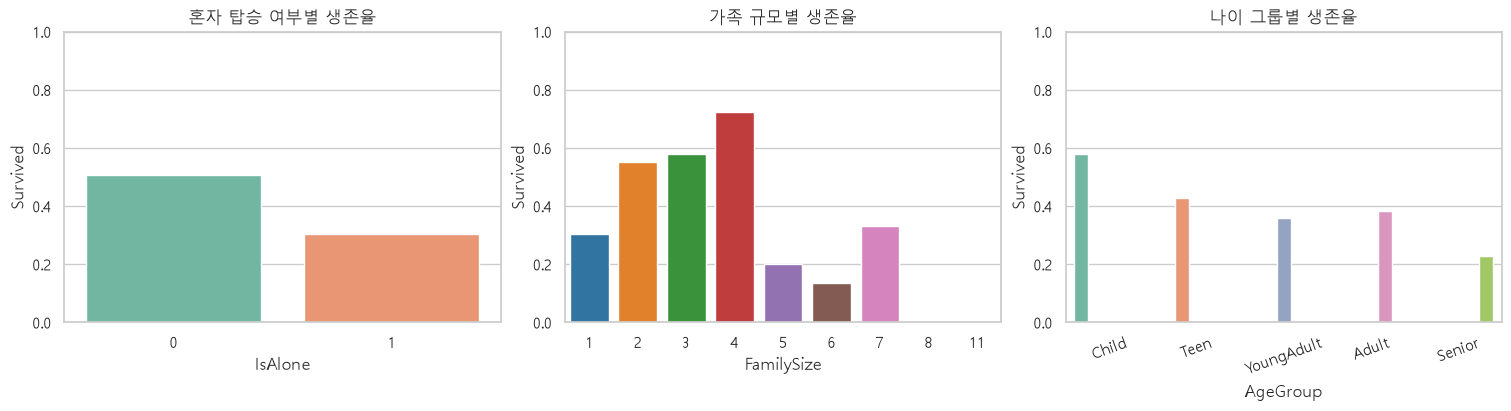

In [99]:
# 목적: 파생변수와 생존율의 관계 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

sns.barplot(data=eda_df, x="IsAlone", y="Survived", hue="IsAlone", palette="Set2", errorbar=None, legend=False, ax=axes[0])
axes[0].set_title("혼자 탑승 여부별 생존율")
axes[0].set_ylim(0, 1)

sns.barplot(data=eda_df, x="FamilySize", y="Survived", hue="FamilySize", palette="tab10", errorbar=None, legend=False, ax=axes[1])
axes[1].set_title("가족 규모별 생존율")
axes[1].set_ylim(0, 1)

sns.barplot(data=eda_df, x="AgeGroup", y="Survived", hue="AgeGroup", palette="Set2", errorbar=None, legend=False, ax=axes[2])
axes[2].set_title("나이 그룹별 생존율")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis="x", rotation=20)

plt.show()

In [100]:
# 모델링 전에 사용할 수 있는 간단한 분석용 데이터셋 예시 생성
model_ready_df = eda_df[[
    "Survived", "Pclass", "Sex", "AgeFilled", "FamilySize", "IsAlone",
    "LogFare", "HasCabin", "EmbarkedFilled",
]].copy()

# get_dummies(): 범주형 변수를 원-핫 인코딩
model_ready_df = pd.get_dummies(
    model_ready_df,
    columns=["Sex", "EmbarkedFilled"],
    dtype=int,
)

print("모델링용 예시 데이터 크기:", model_ready_df.shape)
model_ready_df.head()

모델링용 예시 데이터 크기: (891, 12)


,Survived,Pclass,AgeFilled,FamilySize,IsAlone,LogFare,HasCabin,Sex_female,Sex_male,EmbarkedFilled_C,EmbarkedFilled_Q,EmbarkedFilled_S
0,0,3,22.0,2,0,2.110213,0,0,1,0,0,1
1,1,1,38.0,2,0,4.280593,1,1,0,1,0,0
2,1,3,26.0,1,1,2.188856,0,1,0,0,0,1
3,1,1,35.0,2,0,3.990834,1,1,0,0,0,1
4,0,3,35.0,1,1,2.202765,0,0,1,0,0,1


## 09. Feature Engineering 방향 정리

EDA에서 발견한 패턴과 문제를 바탕으로 새 변수를 만들거나 기존 변수를 변환함.

Titanic 데이터에서는 가족 규모, 혼자 탑승 여부, 나이 그룹, 로그 요금 같은 파생변수를 만들 수 있음.


## 10. 최종 요약 및 인사이트 도출

EDA의 마지막은 그래프가 아니라 **해석 문장**임.

아래 셀은 수업 중 학생들에게 “숫자를 보고 문장으로 바꾸는 방법”을 보여주기 위한 예시임.

# EDA 보고서: Titanic 생존 데이터

## 1. 분석 목적

Titanic 승객 데이터를 탐색하여 생존 여부(`Survived`)와 관련 있어 보이는 변수를 확인하고, 머신러닝 모델링 전에 필요한 전처리 방향과 Feature Engineering 아이디어를 정리함.

핵심 분석 질문:

- 전체 승객의 생존율은 어느 정도인가?
- 성별, 객실 등급, 요금, 나이 등이 생존 여부와 관련이 있는가?
- 결측치와 이상값 후보는 어떤 컬럼에 존재하는가?
- 모델링 전에 어떤 전처리와 파생변수 생성이 필요한가?

## 2. 데이터 개요

- 데이터 출처: Titanic 승객 데이터셋
- 데이터 크기: 891행, 12열
- 한 행의 의미: Titanic에 탑승한 승객 1명
- 타깃 컬럼: `Survived`
  - `0`: 사망
  - `1`: 생존

주요 컬럼:

| 컬럼 | 의미 |
|---|---|
| `PassengerId` | 승객 고유 번호 |
| `Survived` | 생존 여부 |
| `Pclass` | 객실 등급, 1등급이 가장 높은 등급 |
| `Name` | 승객 이름 |
| `Sex` | 성별 |
| `Age` | 나이 |
| `SibSp` | 함께 탑승한 형제/배우자 수 |
| `Parch` | 함께 탑승한 부모/자녀 수 |
| `Ticket` | 티켓 번호 |
| `Fare` | 요금 |
| `Cabin` | 객실 번호 |
| `Embarked` | 탑승 항구 |

## 3. 데이터 품질 확인

결측치 확인 결과:

| 컬럼 | 결측치 수 | 결측률 |
|---|---:|---:|
| `Cabin` | 687 | 77.1% |
| `Age` | 177 | 19.9% |
| `Embarked` | 2 | 0.2% |

중복 확인 결과:

- 전체 중복 행 수: 0개
- `PassengerId` 중복 수: 0개
- `PassengerId`는 승객 식별자로 사용할 수 있음

이상값 후보:

| 컬럼 | 기준 | 이상값 후보 수 | 해석 |
|---|---|---:|---|
| `Age` | IQR 기준 | 11개 | 매우 나이가 많은 승객이 이상값 후보로 탐지됨 |
| `Fare` | IQR 기준 | 116개 | 높은 요금을 낸 승객이 이상값 후보로 탐지됨 |

주의할 점:

- `Fare`의 큰 값은 입력 오류라기보다 1등급 객실 또는 동승/티켓 특성 때문에 발생한 실제 값일 가능성이 있음.
- 이상값 후보라고 해서 무조건 삭제하지 않고, 의미 있는 극단값인지 먼저 확인해야 함.

## 4. 주요 변수 분포

전체 생존율:

- 전체 승객 891명 중 생존자는 342명
- 전체 생존율은 약 38.4%
- 사망자 비율이 생존자 비율보다 높음

주요 범주형 변수 분포:

- `Pclass`는 3등급 승객이 가장 많음
- `Sex`는 남성 승객이 여성 승객보다 많음
- `Embarked`는 `S` 항구 탑승자가 가장 많음

수치형 변수 분포:

- `Age`는 20~40대 구간에 승객이 많이 분포함
- `Fare`는 낮은 요금 구간에 데이터가 많이 몰려 있고, 일부 높은 요금 값이 존재함
- `Fare`는 오른쪽으로 긴 꼬리를 가진 분포이므로 로그 변환 후보로 볼 수 있음

## 5. 변수 간 관계

성별과 생존율:

| 성별 | 생존율 |
|---|---:|
| female | 74.2% |
| male | 18.9% |

해석:

- 여성 승객의 생존율이 남성 승객보다 훨씬 높음.
- `Sex`는 생존 여부와 관련이 큰 변수로 보임.

객실 등급과 생존율:

| 객실 등급 | 생존율 |
|---|---:|
| 1등급 | 63.0% |
| 2등급 | 47.3% |
| 3등급 | 24.2% |

해석:

- 객실 등급이 높을수록 생존율이 높게 나타남.
- `Pclass`는 생존 여부와 관련이 있는 변수로 보임.

탑승 항구와 생존율:

| 탑승 항구 | 생존율 |
|---|---:|
| C | 55.4% |
| Q | 39.0% |
| S | 33.7% |

해석:

- `C` 항구 탑승자의 생존율이 상대적으로 높게 나타남.
- 다만 탑승 항구 자체가 원인이라기보다, 객실 등급이나 요금 같은 다른 변수와 함께 봐야 함.

나이와 요금:

- 생존자와 사망자의 나이 중앙값은 모두 약 28세로 큰 차이가 두드러지지 않음.
- 생존자의 요금 중앙값은 26.0, 사망자의 요금 중앙값은 10.5로 생존자 쪽 요금이 더 높음.
- 요금은 객실 등급과도 관련이 있으므로 `Pclass`, `Fare`, `Survived`를 함께 해석해야 함.

## 6. 전처리 계획

결측치 처리:

| 컬럼 | 처리 계획 |
|---|---|
| `Age` | 성별과 객실 등급별 중앙값으로 대체하는 방식 고려 |
| `Cabin` | 결측률이 높으므로 원본 객실 번호는 제거하되, 객실 정보 유무를 나타내는 `HasCabin` 생성 고려 |
| `Embarked` | 결측치가 2개뿐이므로 최빈값으로 대체하거나 해당 행 제거 고려 |

컬럼 처리:

| 컬럼 | 처리 방향 |
|---|---|
| `PassengerId` | 식별자이므로 모델 입력에서는 제외 가능 |
| `Name` | 바로 사용하기 어렵지만 호칭 추출 같은 추가 Feature Engineering 가능 |
| `Ticket` | 고유값이 많아 기본 모델에서는 제외 가능 |
| `Cabin` | 결측률이 높아 원본 컬럼은 제외하거나 객실 정보 유무만 활용 |

인코딩:

- `Sex`, `Embarked`는 범주형 변수이므로 수치형으로 변환 필요
- `get_dummies()`를 이용한 원-핫 인코딩 가능

스케일링/변환:

- `Fare`는 값의 치우침이 있으므로 `np.log1p()`를 이용한 로그 변환 고려

## 7. Feature Engineering 아이디어

생성 가능한 파생변수:

| 파생변수 | 생성 방법 | 기대 효과 |
|---|---|---|
| `FamilySize` | `SibSp + Parch + 1` | 함께 탑승한 가족 규모 확인 |
| `IsAlone` | `FamilySize == 1` | 혼자 탑승했는지 여부 확인 |
| `AgeGroup` | `Age`를 구간화 | 나이대별 생존율 비교 가능 |
| `LogFare` | `np.log1p(Fare)` | 요금 분포의 치우침 완화 |
| `HasCabin` | `Cabin` 결측 여부 | 객실 정보 보유 여부 활용 |

Feature Engineering 방향:

- 가족 규모가 너무 크거나 혼자 탑승한 경우 생존율이 달라지는지 확인
- 나이를 그대로 쓰는 것보다 나이 그룹으로 나누면 해석이 쉬워질 수 있음
- `Fare`는 큰 값의 영향이 있으므로 로그 변환 후 사용하는 것이 모델에 유리할 수 있음

## 8. 최종 인사이트

1. 전체 생존율은 약 38.4%로, 사망자 비율이 더 높음.
2. 여성 생존율은 약 74.2%, 남성 생존율은 약 18.9%로 성별에 따른 생존율 차이가 큼.
3. 1등급 생존율은 약 63.0%, 3등급 생존율은 약 24.2%로 객실 등급이 높을수록 생존율이 높게 나타남.
4. `Age`는 약 19.9%의 결측치가 있어 대체 전략이 필요함.
5. `Cabin`은 약 77.1%가 결측치이므로 원본 컬럼을 그대로 쓰기보다 `HasCabin` 같은 파생변수로 활용하는 것이 적절함.
6. `Fare`는 오른쪽으로 치우친 분포와 이상값 후보가 있으므로 로그 변환을 고려할 수 있음.
7. 머신러닝으로 넘어가기 전 `Sex`, `Pclass`, `AgeFilled`, `FamilySize`, `IsAlone`, `LogFare`, `HasCabin`, `Embarked` 등을 주요 입력 변수 후보로 사용할 수 있음.

다음 단계:

- 결측치 처리 적용
- 범주형 변수 인코딩
- 파생변수 생성
- 학습용 Feature/Target 분리
- 머신러닝 모델 학습 및 평가